# Nucleosome Repeat Length (NRL) and Effective Protection Size Simulations
This notebook estimates nucleosome repeat length (NRL) and effective nucleosome protection size in plasma cell-free DNA. We simulate cfDNA fragmentation from chromatin with active vs. inactive nucleosome configurations, then use grid search to identify the NRL and protection size parameters that best reproduce observed log ratio of fragment abundances between active and inactive enhancers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import time
import itertools as it
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from scipy.stats import spearmanr


In [2]:
def make_nuc_coverage(NRL, effect_size, n_nucs=4, shape=4):

    centers = np.arange(n_nucs) * NRL + effect_size / 2
    length = int(centers[-1] + effect_size / 2)
    x = np.arange(length)

    coverage = np.zeros(length, dtype=float)

    half = effect_size / 2

    for c in centers:
        d = np.abs(x - c) / half
        coverage += np.exp(-(d ** shape))

    return x, coverage

def coverage_to_cut_prob(cov, cut_expo=0.05, cut_pro=0.001):
    return cut_expo + cov * (cut_pro - cut_expo)

def sample_fragment_counts(prob, n_repeat, rng, max_len=None):
    big_prob = np.tile(prob, n_repeat)

    cut_pos = np.flatnonzero(rng.random(big_prob.size) < big_prob)
    frags = np.diff(np.r_[0, cut_pos, big_prob.size])

    if max_len is None:
        max_len = frags.max()

    counts = np.bincount(frags, minlength=max_len + 1)

    return counts

def evaluate(p):
    NRL_AC, EFF_AC, NRL_IN, EFF_IN = p
    rng = np.random.default_rng(1)

    _, cov1 = make_nuc_coverage(NRL_AC, EFF_AC, 100, 4)
    _, cov2 = make_nuc_coverage(NRL_IN, EFF_IN, 100, 4)

    c1 = sample_fragment_counts(coverage_to_cut_prob(cov1), 1000, rng)
    rng = np.random.default_rng(1)
    c2 = sample_fragment_counts(coverage_to_cut_prob(cov2), 1000, rng)

    c1 = np.pad(c1, (0, max(0, 501-len(c1))))
    c2 = np.pad(c2, (0, max(0, 501-len(c2))))

    simul = np.log2((c1[100:501]+1)/(c2[100:501]+1))
#     return (*p, pearsonr(ref, simul)[0])
    return (*p, spearmanr(ref, simul)[0])



In [3]:
ref = pd.read_csv('./obs.csv', index_col=0)['obs'].values

In [4]:
params = list(it.product(
    range(160, 190, 3),   # NRL_AC
    range(143, 173, 3),   # EFF_AC
    range(160, 190, 3),   # NRL_IN
    range(143, 173, 3)    # EFF_IN
))
params = [p for p in params if p[0] != p[2]]

In [5]:
STT=time.time()
results = Parallel(n_jobs=40)(
    delayed(evaluate)(p) for p in params
)

df = pd.DataFrame(results, columns=["NRL_AC","EFF_AC","NRL_IN","EFF_IN","r"])
df = df.sort_values("r", ascending=False).reset_index(drop=True)

print(time.time()-STT)

136.1584975719452


In [6]:
best = df.loc[df['r'].idxmax()]

params = list(it.product(
    range(int(best.NRL_AC)-3, int(best.NRL_AC)+4, 1),
    range(int(best.EFF_AC)-3, int(best.EFF_AC)+4, 1),
    range(int(best.NRL_IN)-3, int(best.NRL_IN)+4, 1),
    range(int(best.EFF_IN)-3, int(best.EFF_IN)+4, 1),
))
params = [p for p in params if p[0] != p[2]]

In [7]:
STT=time.time()
results = Parallel(n_jobs=40)(
    delayed(evaluate)(p) for p in params
)

df2 = pd.DataFrame(results, columns=["NRL_AC","EFF_AC","NRL_IN","EFF_IN","r"])
df2 = df2.sort_values("r", ascending=False).reset_index(drop=True)

print(time.time()-STT)

34.57629752159119


In [8]:
df2.loc[0]

NRL_AC    163.000000
EFF_AC    164.000000
NRL_IN    186.000000
EFF_IN    173.000000
r           0.940281
Name: 0, dtype: float64

In [9]:
NRL_AC, EFF_AC, NRL_IN, EFF_IN, _ = df2.loc[0]

In [10]:
x, cov = make_nuc_coverage(NRL=NRL_AC,effect_size=EFF_AC,n_nucs=100)
prob = coverage_to_cut_prob(cov)
rng = np.random.default_rng(1)

counts = sample_fragment_counts(
    prob,
    n_repeat=1000,
    rng=rng
)
x2, cov2 = make_nuc_coverage(NRL=NRL_IN,effect_size=EFF_IN,n_nucs=100)
prob2 = coverage_to_cut_prob(cov2)
rng = np.random.default_rng(1)

counts2 = sample_fragment_counts(
    prob2,
    n_repeat=1000,
    rng=rng
)

In [11]:
simul = np.log2((counts[100:501]+1)/(counts2[100:501]+1))

Text(0.5, 0, 'Fragment size (bp)')

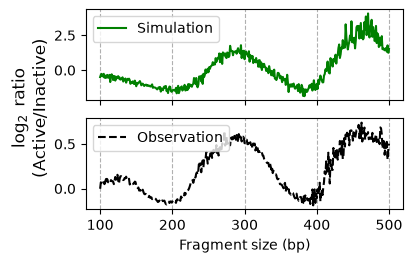

In [20]:
fig, ax = plt.subplots(2,1, figsize=(4.1,2.6), sharex=True)

ax[0].plot(range(100,501),simul,color='green',
          label='Simulation')
ax[1].plot(range(100,501),ref, color='black', linestyle='--',
          label='Observation')

for a in ax:
    a.grid(axis='x', linestyle='--')
    a.legend()
fig.supylabel(
    r'$\log_{2}$ ratio' + '\n(Active/Inactive)',
    x=-0.01,
    va='center',
    ha='center',
    multialignment='center'
)
ax[1].set_xlabel('Fragment size (bp)')

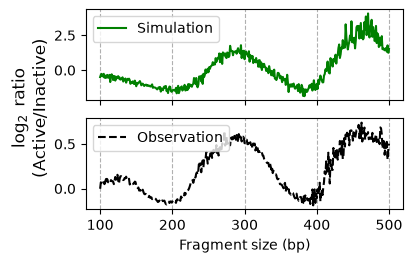

In [19]:
fig, ax = plt.subplots(2,1, figsize=(4.1,2.6), sharex=True)

ax[0].plot(range(100,501),simul,color='green',
          label='Simulation')
ax[1].plot(range(100,501),ref, color='black', linestyle='--',
          label='Observation')

for a in ax:
    a.grid(axis='x', linestyle='--')
    a.legend()
fig.supylabel(
    r'$\log_{2}$ ratio' + '\n(Active/Inactive)',
    x=-0.01,
    va='center',
    ha='center',
    multialignment='center'
)
ax[1].set_xlabel('Fragment size (bp)')
plt.savefig('new_3b.svg')